## Objective: Understanding the training loss 

The exponential family is defined by the following likelihood: 
$$
p(y\mid x, S) = \frac{\exp(f_{\theta}^{\top}(x)g_{\theta}(y))}{\sum_{y'\in S} \exp(f_{\theta}^{\top}(x)g_{\theta}(y'))}
$$

Taking the log, we can derive the log-likelihood and then the loss: 
$$
\begin{align}
\log p(y\mid x, S) &= f_{\theta}^{\top}(x)g_{\theta}(y) - \log\left(\sum_{y'\in S} \exp(f_{\theta}^{\top}(x)g_{\theta}(y'))\right)
\\
\mathcal{L} &= - \log p(y\mid x, S)
\end{align}
$$

It can be shown that this objective is equivalent to the InfoNCE loss objective: 
$$
\begin{align}
...
\end{align}
$$

First, let's try to code the loss for discrete random variables

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
def f(x): 
    return x

def g(y): 
    return y

In [3]:
from scipy.special import logsumexp
batch_size = 100
latent_ndims = 1
labels = np.array([0, 1, 2, 3, 4, 5]) 
x = np.random.choice(labels, size = (batch_size, latent_ndims))
y = x.copy()
def normalize(z):
    return z / np.linalg.norm(z, axis=1, keepdims=True)

z_y_classes = np.eye(6) 
z_x = z_y_classes[np.searchsorted(labels, x.flatten())] 
# z_x = normalize(f(x))
z_y = z_x.copy()
# z_y_classes = normalize(labels[:, None]) # (num_classes, latent_dims)

# Computing the log normalization for each sample of the batch 
norm_input = z_x @ z_y_classes.T # (batch_size, num_classes)
log_normalization = logsumexp(norm_input, axis = 1)

# Computing the similarity score
similarity_matrix = z_x @ z_y.T
similarity_score = np.diag(similarity_matrix)
loss = - np.mean(similarity_score - log_normalization)


In [4]:
from sklearn.datasets import make_moons
import numpy as np
# samples = make_moons(n_samples=100_000)
dset_size = 100_000
samples_a = 0.1 * np.random.normal(size = (dset_size, 2))
labels_a = np.zeros(len(samples_a))

samples_b = 2 + 0.1 * np.random.normal(size = (dset_size, 2))
labels_b = np.ones(len(samples_b))

samples = np.concatenate([samples_a, samples_b])
labels = np.concatenate([labels_a, labels_b])

In [ ]:
from datasets import Dataset

dset = Dataset.from_dict({
    "image": samples,
    "theta": labels.astype(np.float32)
})
dset = dset.shuffle(seed =42)
dset = dset.train_test_split(train_size = 0.8, test_size = 0.2)
path = "C:/Users/Admin/Desktop/Research/Projects/classes/causal_representation/data/twomoons_2d"
dset.save_to_disk(path)

c:\Users\Admin\Desktop\Research\Projects\classes\causal_representation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Saving the dataset (1/1 shards): 100%|██████████| 40000/40000 [00:00<00:00, 93636.02 examples/s] 


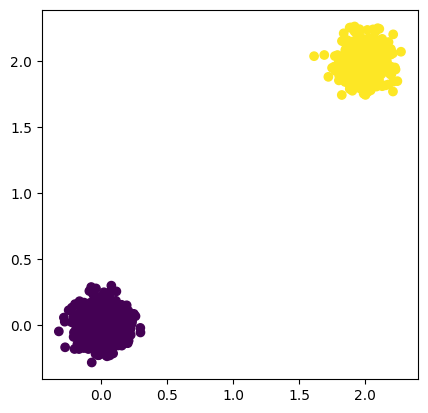

In [9]:
from datasets import load_from_disk
dset = load_from_disk(path)
dset = dset.with_format("numpy")
data = dset["train"][:1000]
samples = data["image"]
labels = data["theta"] 
plt.scatter(*samples.T, c = labels)
# plt.scatter(*samples_b.T)
plt.gca().set_aspect("equal")

In [1]:
from astro_peek.utils import load_yaml
from astro_peek.trainer import training
from astro_peek.nets.architectures.cnn import CNN
dset_name = "two_moons"
cfg_dir = f"../../astro_peek/configs/{dset_name}.yaml"
cfg = load_yaml(cfg_dir)
print(cfg)
encoder_features, encoder_labels, loss = training(cfg)

c:\Users\Admin\Desktop\Research\Projects\classes\causal_representation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'encoder_features': {'backbone': 'mlp', 'backbone_cfg': {'input_dim': 2, 'layer_widths': [32, 32, 32], 'output_dim': 2, 'activation_func': 'silu', 'activate_final': False}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/rings/encoder_features'}, 'encoder_labels': {'backbone': 'mlp', 'backbone_cfg': {'input_dim': 1, 'layer_widths': [32, 32, 32], 'output_dim': 2, 'activation_func': 'silu', 'activate_final': False}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/rings/encoder_labels'}, 'data': {'path': 'C:/Users/Admin/Desktop/Research/Projects/classes/causal_representation/data/two_moons', 'data_split': None}, 'trainer': {'epochs': 10, 'optimizer': 'adam', 'batch_size': 4096, 'lr': '1e-2', 'seed': 43, 'device': 'auto', 'normalize': True, 'transform': None}}
training set size:  (80000, 2)
test set size:  (20000, 2)
Running on device cpu
10


Loss = 7.75: 100%|██████████| 10/10 [02:02<00:00, 12.27s/it]

Saving encoder features model
Saving encoder labels model


In [2]:
from datasets import load_from_disk
path = f"C:/Users/Admin/Desktop/Research/Projects/classes/causal_representation/data/{dset_name}"
dset = load_from_disk(path)
dset = dset.with_format("torch")
data = dset["train"][:1000]
x = data["image"]
y = data["theta"].unsqueeze(1)

In [3]:
z_x = encoder_features(x).detach()
z_y = encoder_labels(y).detach()

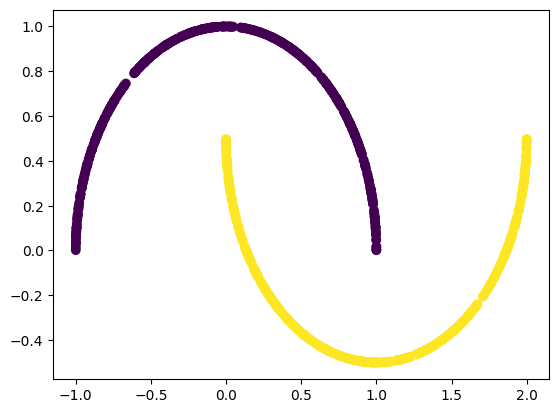

In [5]:
import matplotlib.pyplot as plt 
plt.scatter(*x.T, c = y)

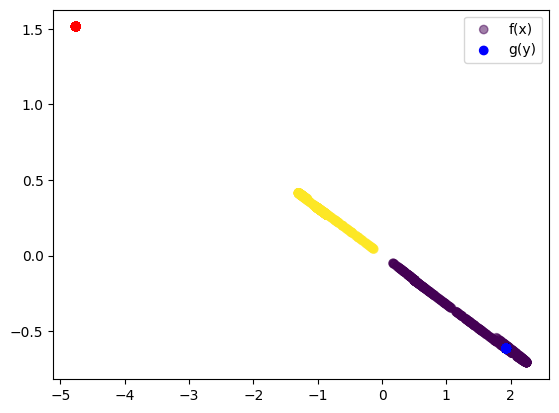

In [4]:
import matplotlib.pyplot as plt 
from matplotlib.colors import Normalize

norm = Normalize(vmin = 0, vmax = 1)
twilight = plt.get_cmap("bwr")
plt.scatter(*z_x.T, c = y, alpha = 0.5, label = "f(x)")
plt.scatter(*z_y.T, c = y, cmap = twilight, norm = norm, label = "g(y)")
plt.legend()
# plt.gca().set(xlim = [-1, 1], ylim = [-1, 1])

In [6]:
z_y

tensor([[ 0.2328, -0.0942],
        [ 0.2328, -0.0942],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [ 0.2328, -0.0942],
        [ 0.2328, -0.0942],
        [ 0.2328, -0.0942],
        [ 0.2328, -0.0942],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [-0.2298,  0.0930],
        [ 0.2328, -0.0942],
        [ 0.2328, -0

In [8]:
for a in zip(None, None, None):
    print("Hey")

TypeError: 'NoneType' object is not iterable

In [136]:
cfg["trainer"]["seed"]

42

In [122]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [120]:
np.exp(np.mean(similarity_score - log_normalization))

np.float64(0.3521874283517514)

In [111]:
similarity_matrix.shape

(100, 100)

In [112]:
similarity_score - log_normalization

array([-1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04359178,
       -1.04359178, -1.04359178, -1.04359178, -1.04359178, -1.04

In [114]:
loss

np.float64(1.043591778185858)

In [19]:
similarity_matrix.shape

(100, 100)

In [14]:
y.shape

(100, 2)

In [10]:
(z_x @ z_y.T).shape

(100, 100)

In [6]:
z_x.shape

(2,)